# goals
* explore the mismatch between lensed, RP and NP waveforms
* explore the conditions for indistinguishable waveforms

# import modules

In [ ]:
from lensing_and_precession.modules.waveform_plotting import *

# assign params

In [19]:
def_td = 0.03
def_I = 0.5
def_y = get_y_from_I(def_I)
def_MLz = get_MLz_from_td(def_td, def_y)
print(f"Default source position y = {def_y:.2f} (I = {def_I})")
print("Default lens mass MLz = {:.3f} solar masses".format(def_MLz))

# Optional cosmological redshift (source-frame -> detector-frame).
z = None  # set e.g. 0.1 to enable redshifted mass/dist

lens_params_1["y"] = def_y
lens_params_1["MLz"] = def_MLz * solar_mass
lens_params_1, RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["edgeon"], lens_params_1, RP_params_1, NP_params_1
)

print(
    "Chirp mass (source frame) = {:.3f} solar masses".format(
        lens_params_1["mcz"] / solar_mass
    )
)

# Match contour_L_NP_mcz_td.py behavior: apply z to waveform parameter dicts.
if z is not None:
    apply_z(lens_params_1, z)
    apply_z(RP_params_1, z)
    apply_z(NP_params_1, z)
    print(f"Applied redshift z={z} (mcz treated as source-frame)")

print(
    "Chirp mass (detector frame) = {:.3f} solar masses".format(
        lens_params_1["mcz"] / solar_mass
    )
)

Default source position y = 0.35 (I = 0.5)
Default lens mass MLz = 2174.547 solar masses
Chirp mass (source frame) = 20.000 solar masses
Chirp mass (detector frame) = 20.000 solar masses


In [34]:
def_td = 0.03
def_I = 0.5
def_y = get_y_from_I(def_I)
def_MLz = get_MLz_from_td(def_td, def_y)
print(f"Default source position y = {def_y:.2f} (I = {def_I})")
print("Default lens mass MLz = {:.3f} solar masses".format(def_MLz))

# Optional cosmological redshift (source-frame -> detector-frame).
z = 1  # set e.g. 0.3 to enable redshifted mass/dist

lens_params_1["y"] = def_y
lens_params_1["MLz"] = def_MLz * solar_mass
lens_params_1, RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["edgeon"], lens_params_1, RP_params_1, NP_params_1
)

print(
    "Chirp mass (source frame) = {:.3f} solar masses".format(
        lens_params_1["mcz"] / solar_mass
    )
)

# Match contour_L_NP_mcz_td.py behavior: apply z to waveform parameter dicts.
if z is not None:
    apply_z(lens_params_1, z)
    apply_z(RP_params_1, z)
    apply_z(NP_params_1, z)
    print(f"Applied redshift z={z} (mcz treated as source-frame)")

print(
    "Chirp mass (detector frame) = {:.3f} solar masses".format(
        lens_params_1["mcz"] / solar_mass
    )
)

Default source position y = 0.35 (I = 0.5)
Default lens mass MLz = 2174.547 solar masses
Chirp mass (source frame) = 20.000 solar masses
Applied redshift z=1 (mcz treated as source-frame)
Chirp mass (detector frame) = 40.000 solar masses


# lensing

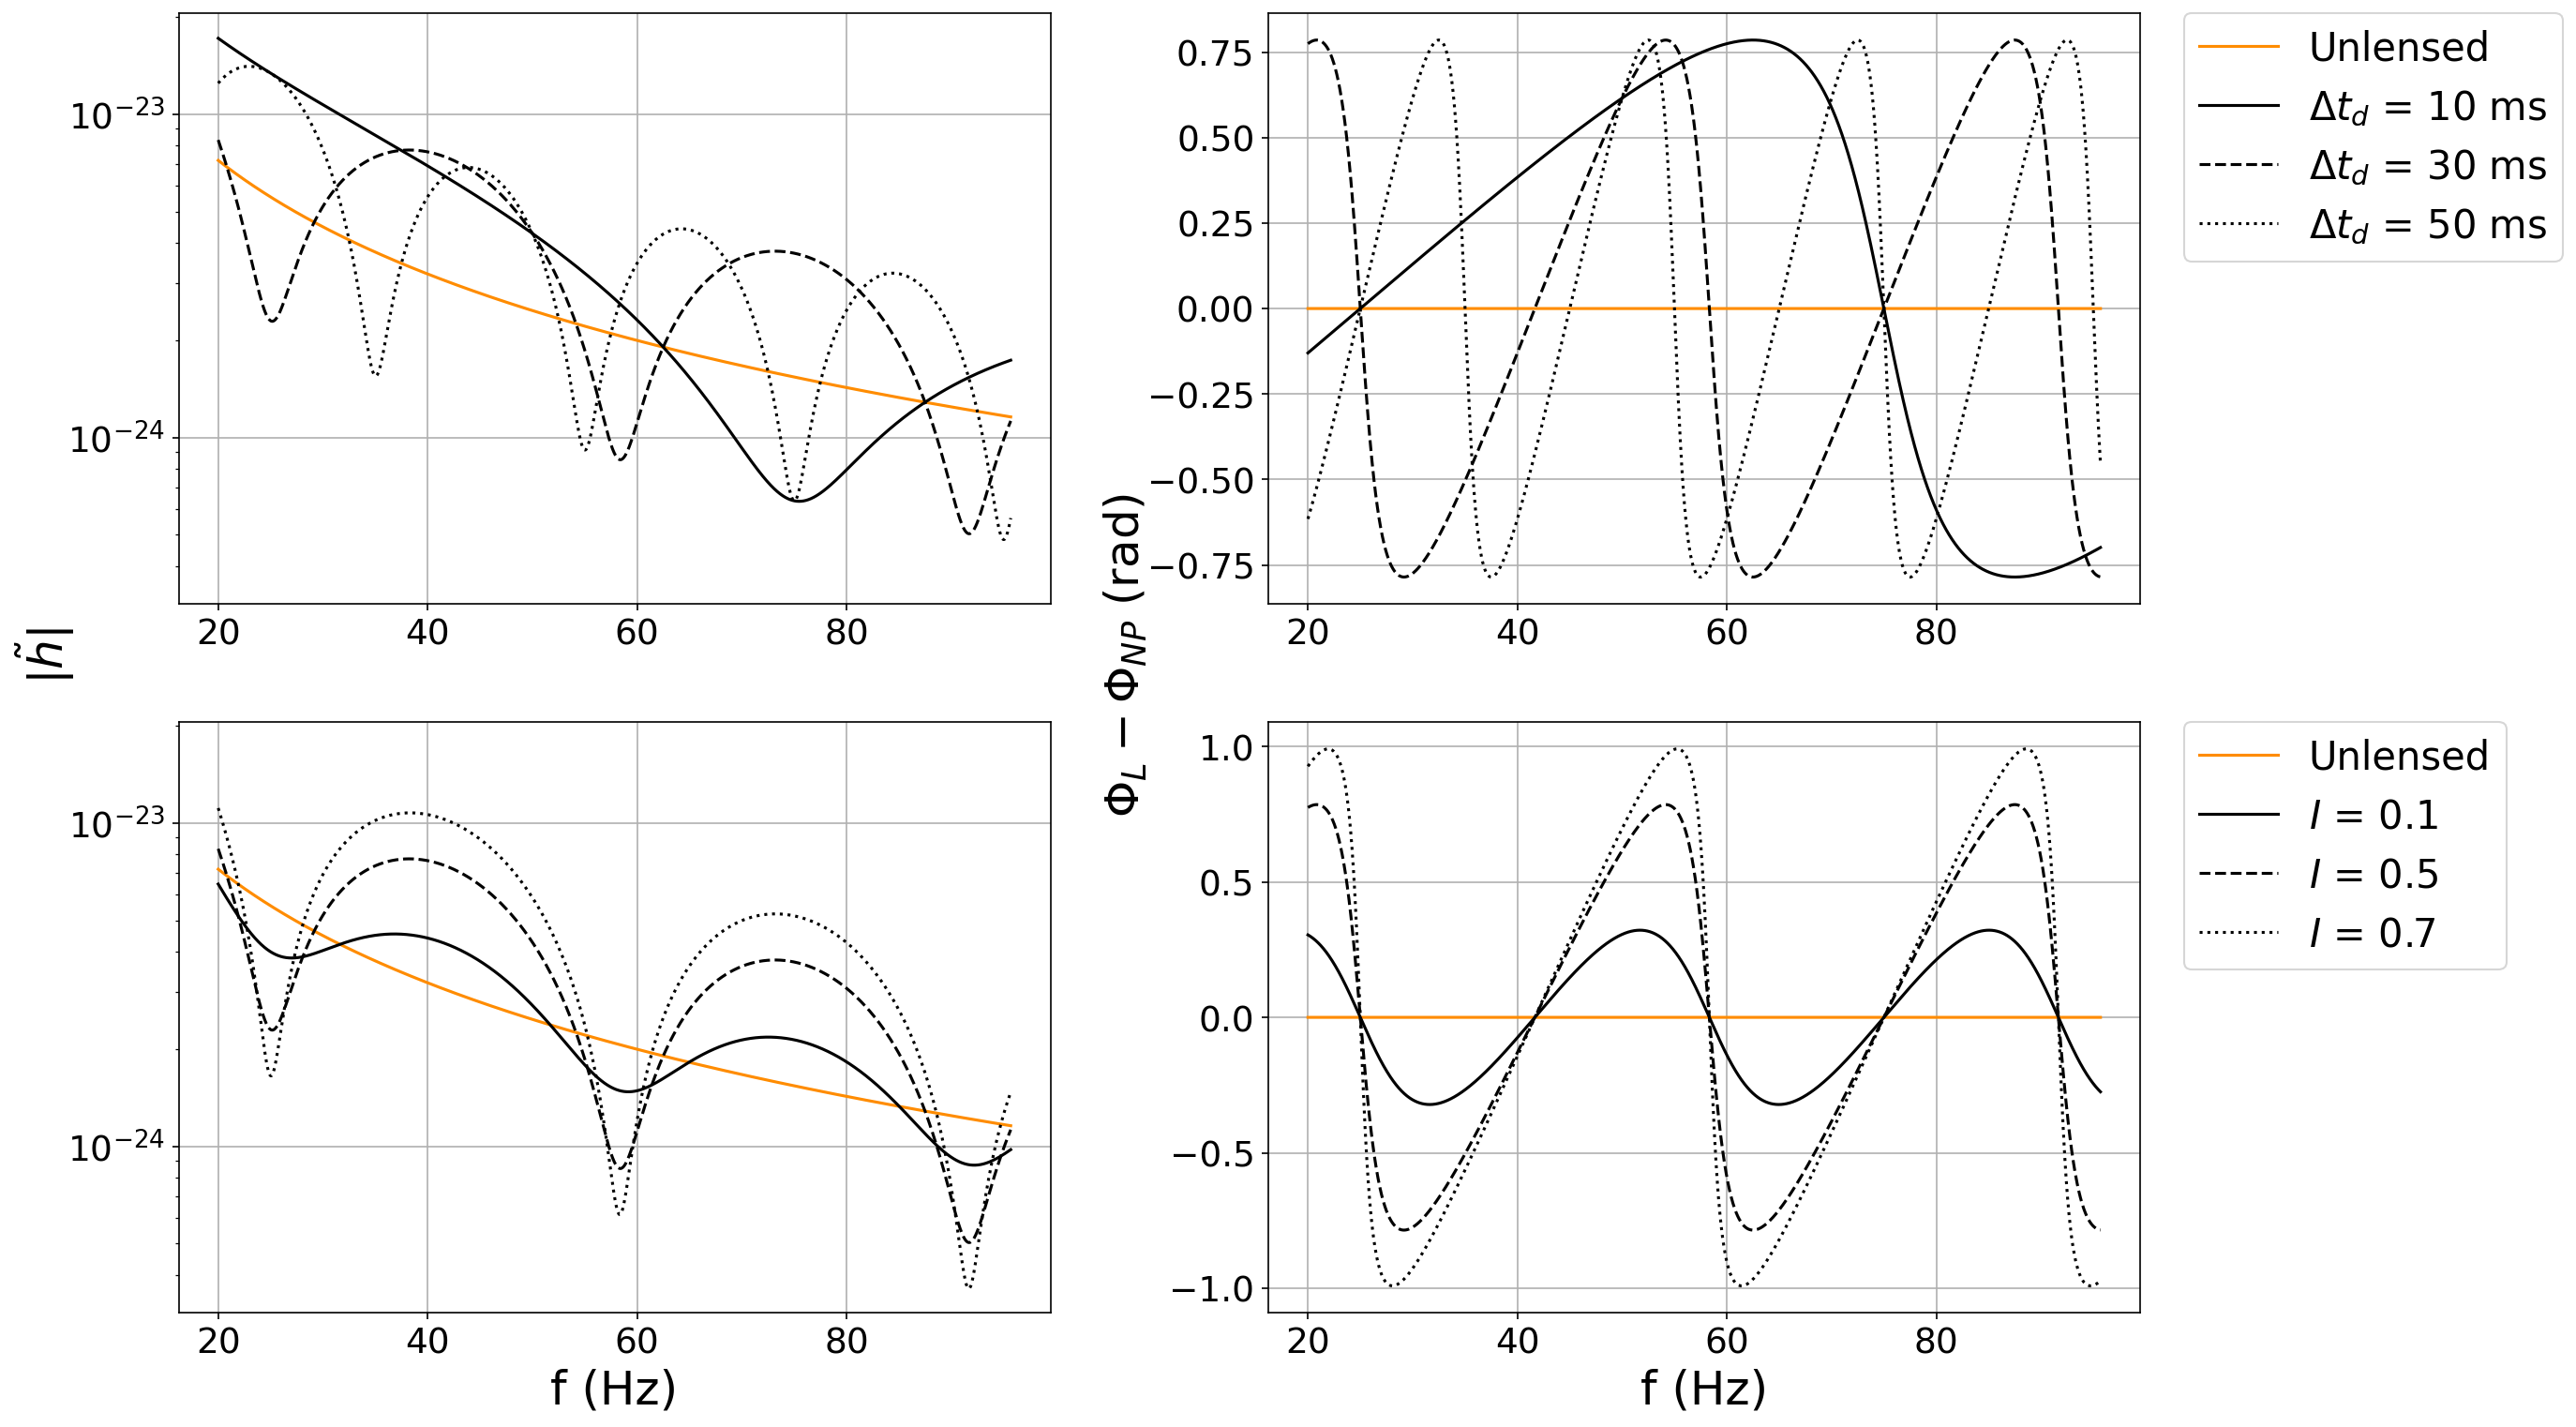

In [ ]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    z=z,
)

Applied redshift z=1 (mcz treated as source-frame)


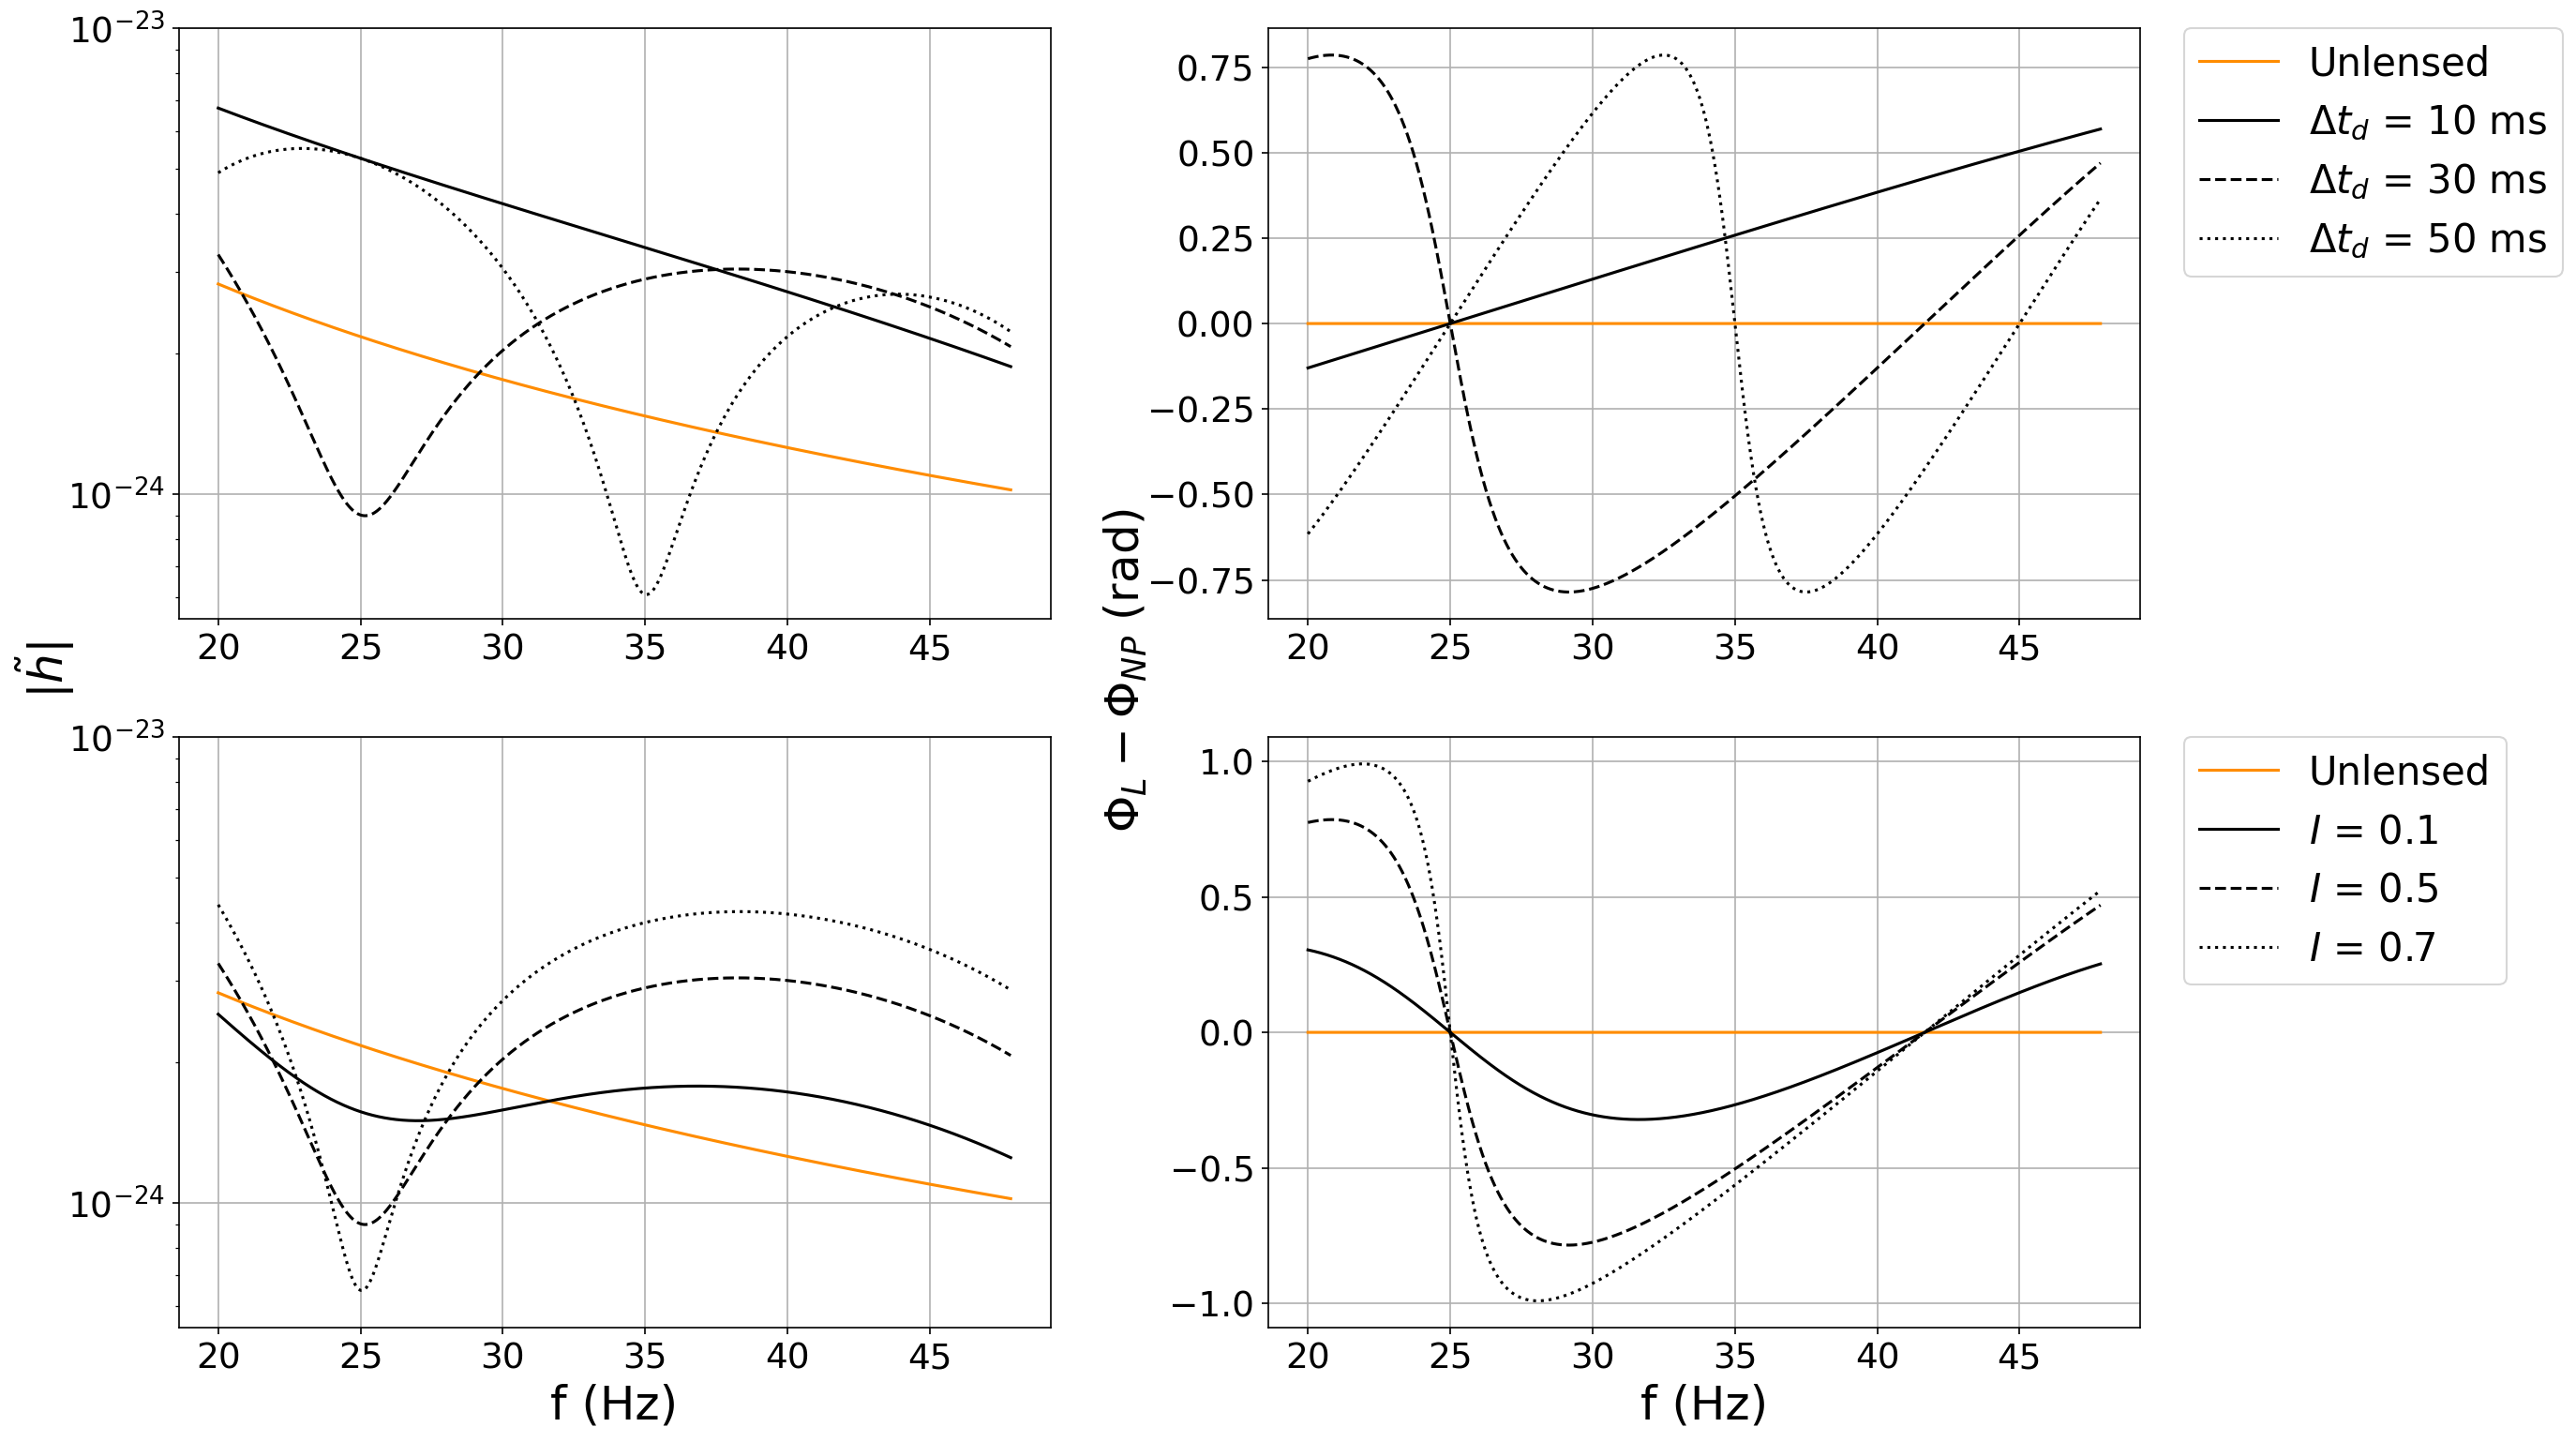

In [35]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    z=z,
)

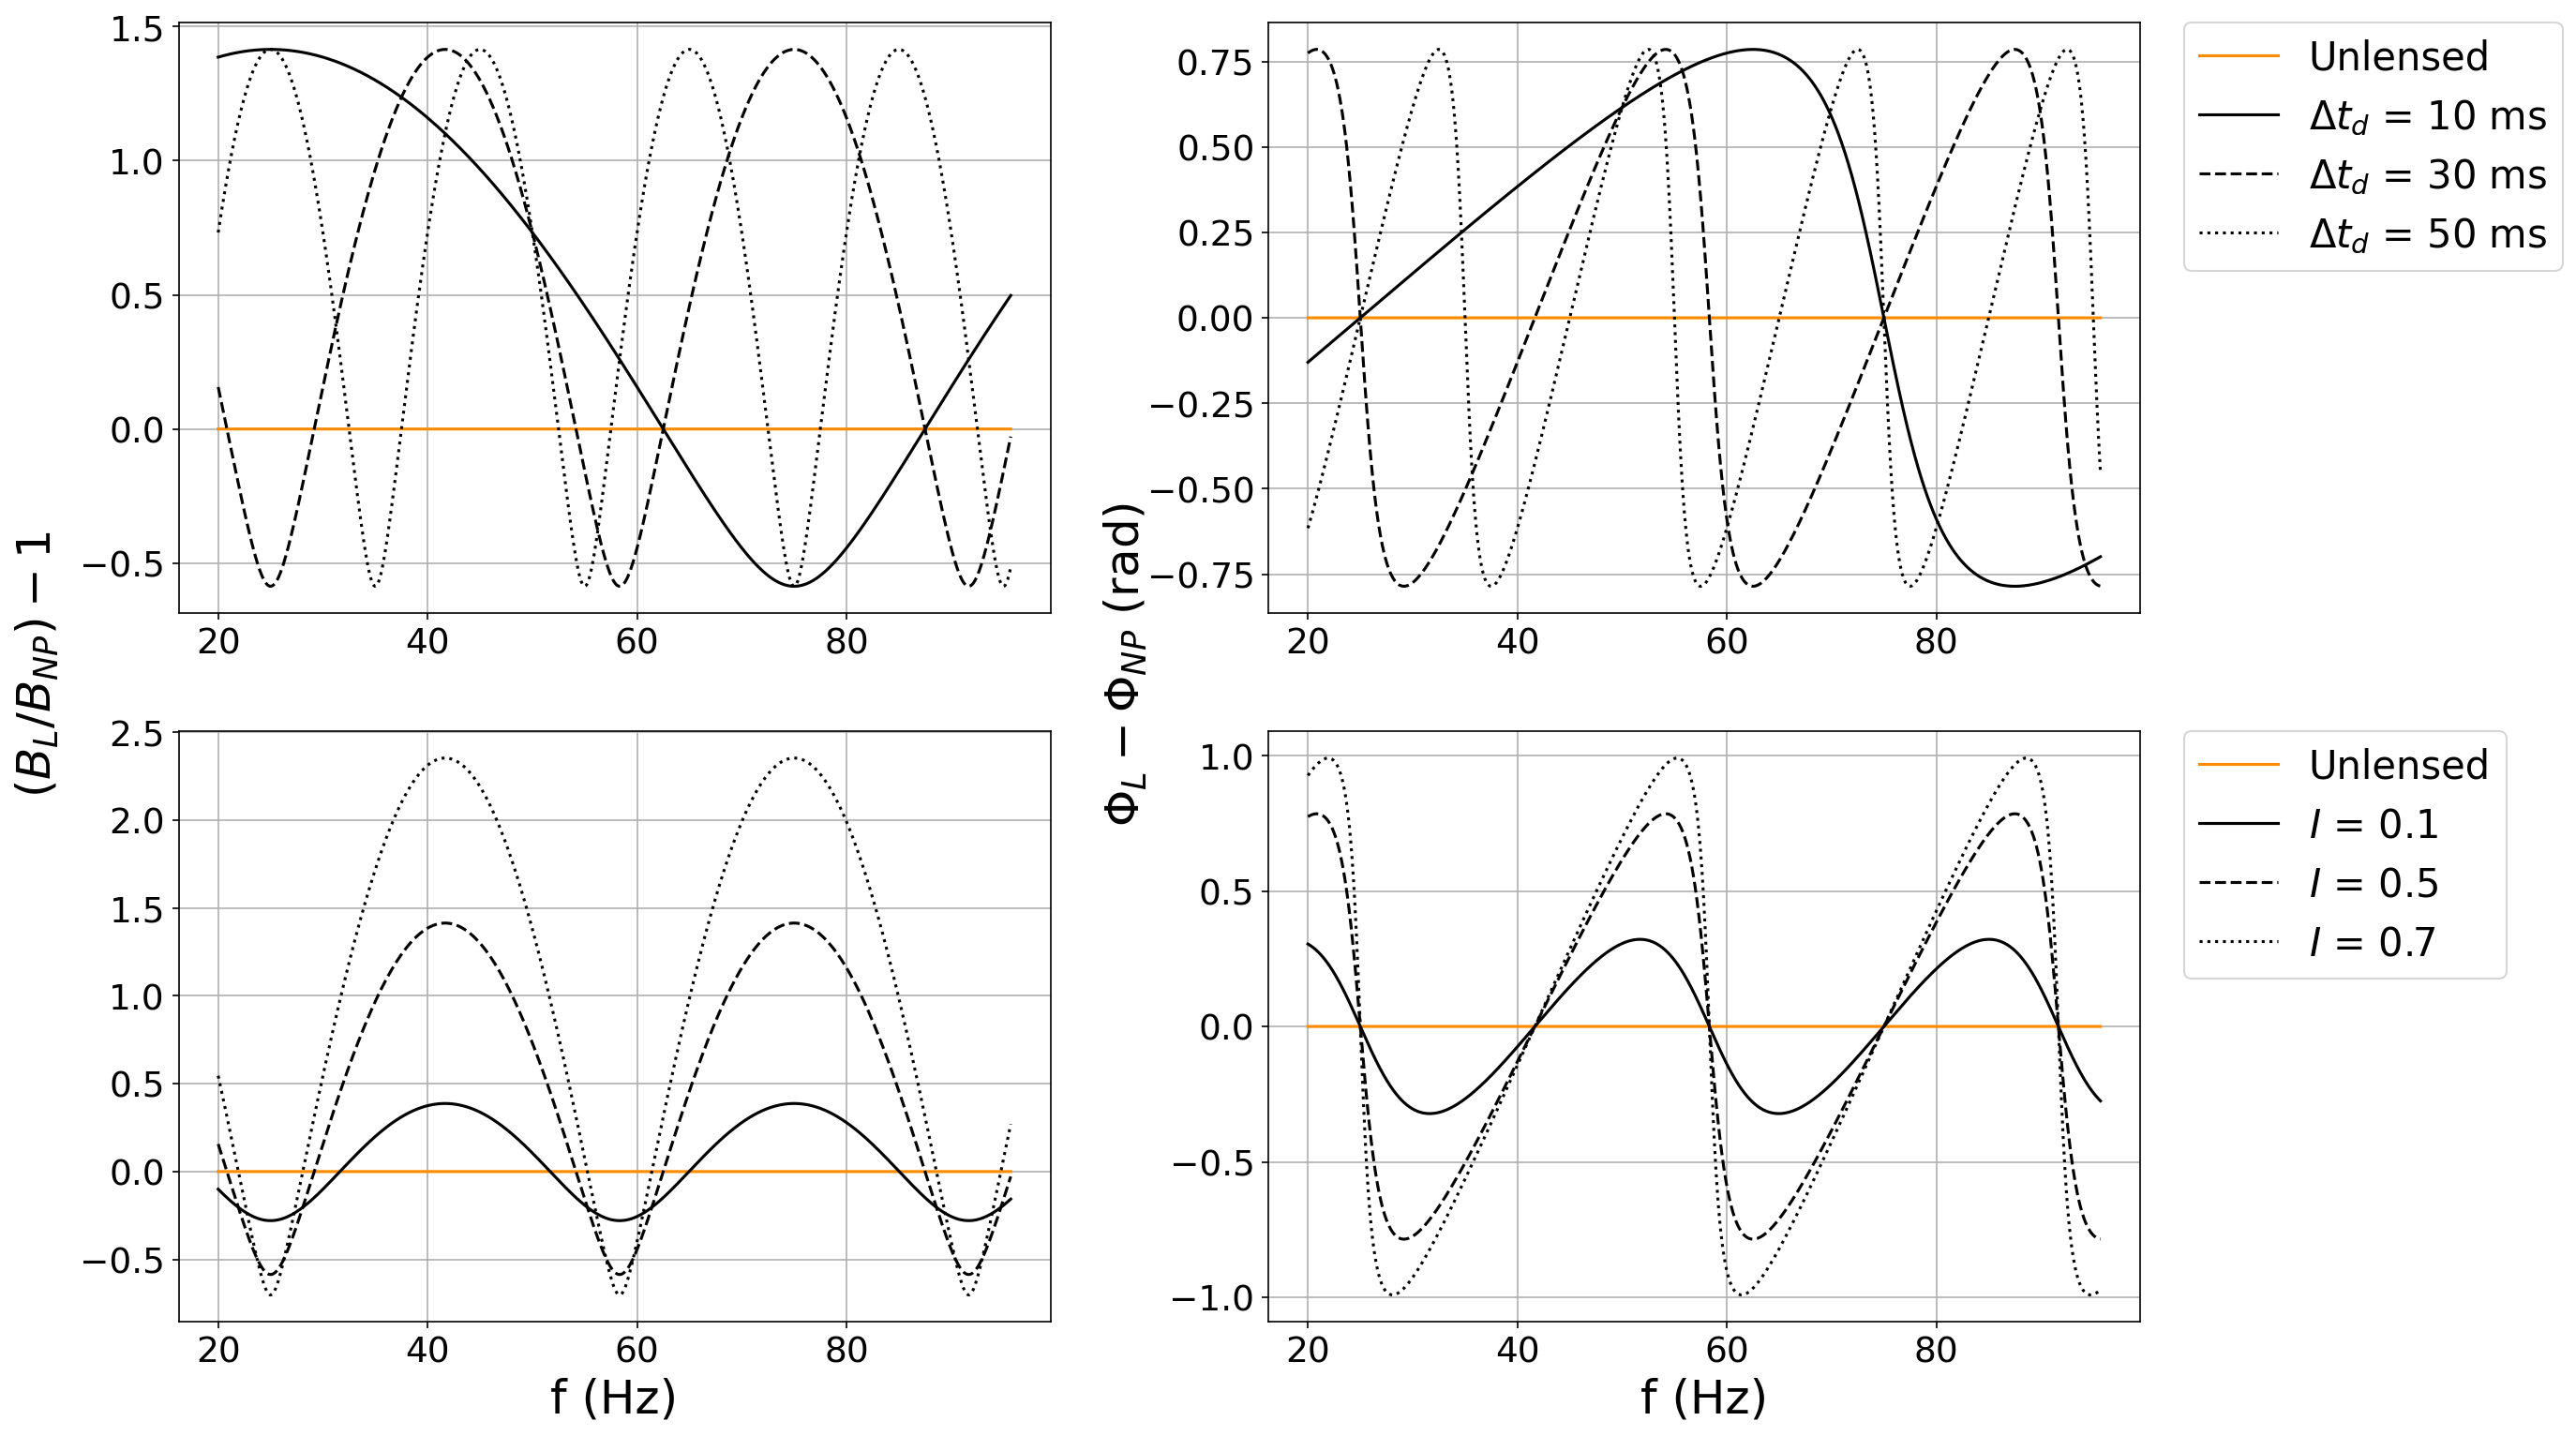

In [ ]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    z=z,
    save_path="../figures/waveforms_lensed.pdf",
)

Applied redshift z=1 (mcz treated as source-frame)


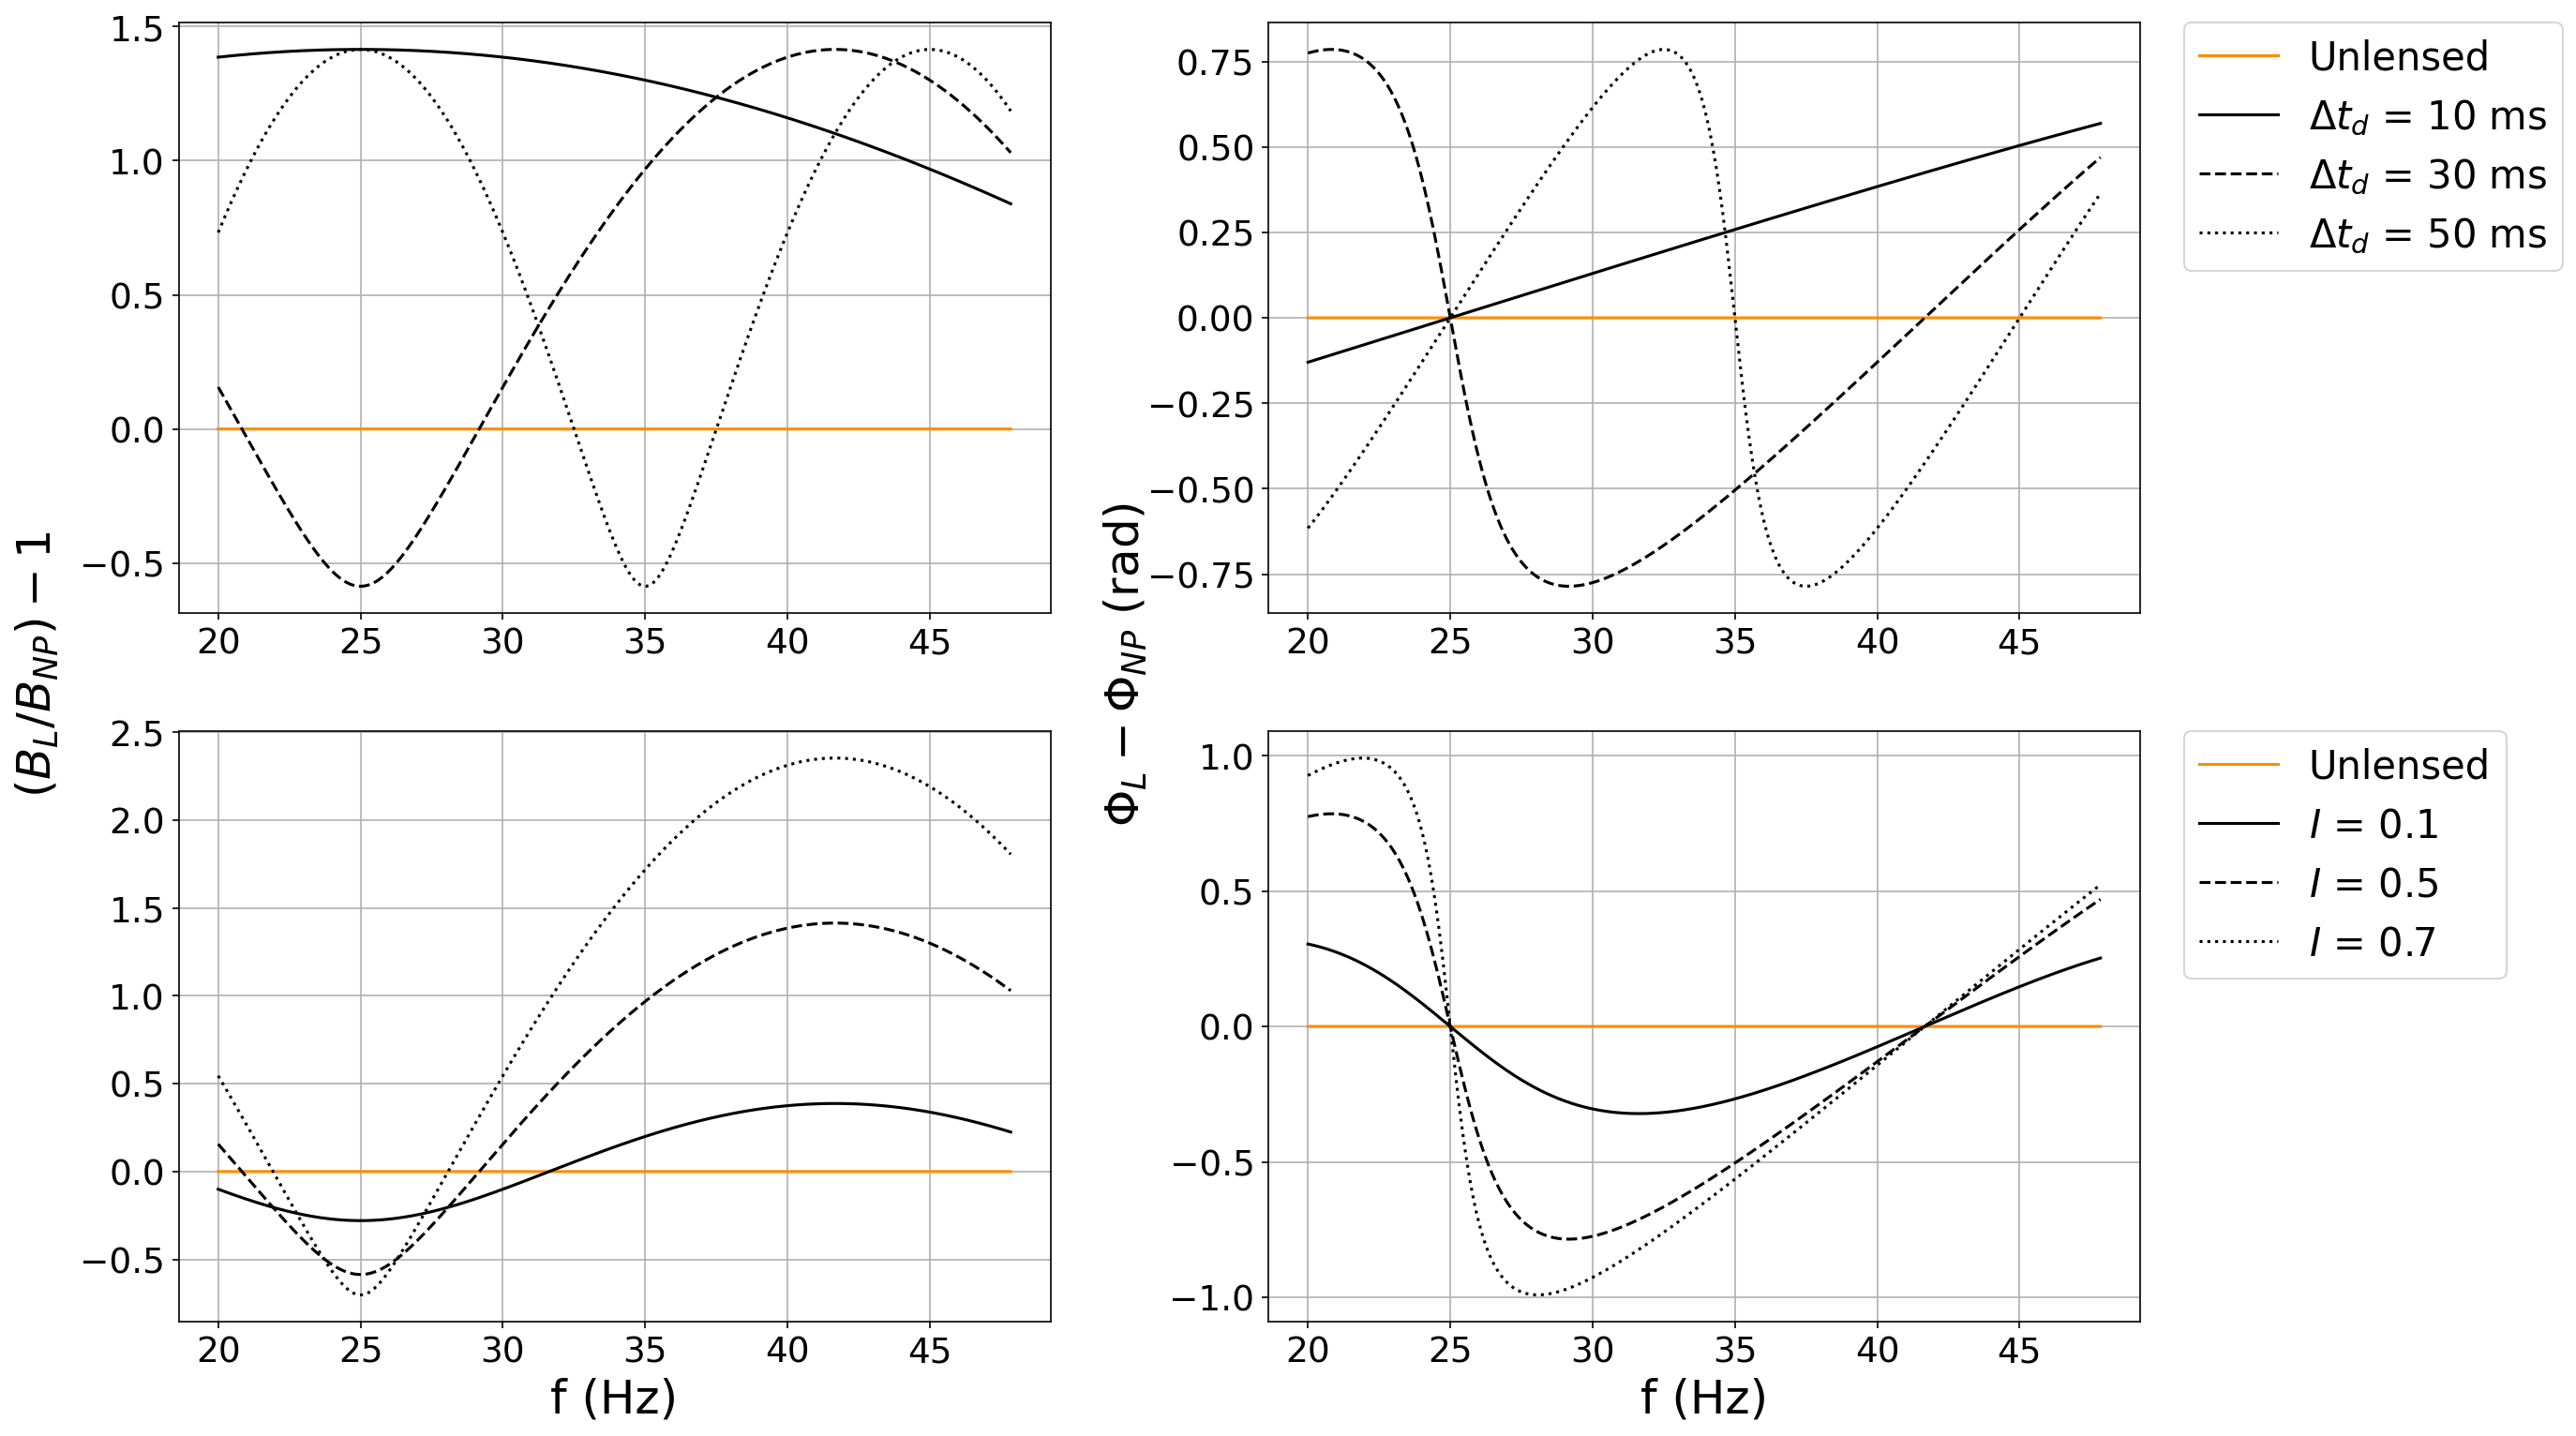

In [36]:
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    z=z,
    save_path="../figures/waveforms_lensed.pdf",
)

# precessing

## random

system 3 in Taman's paper


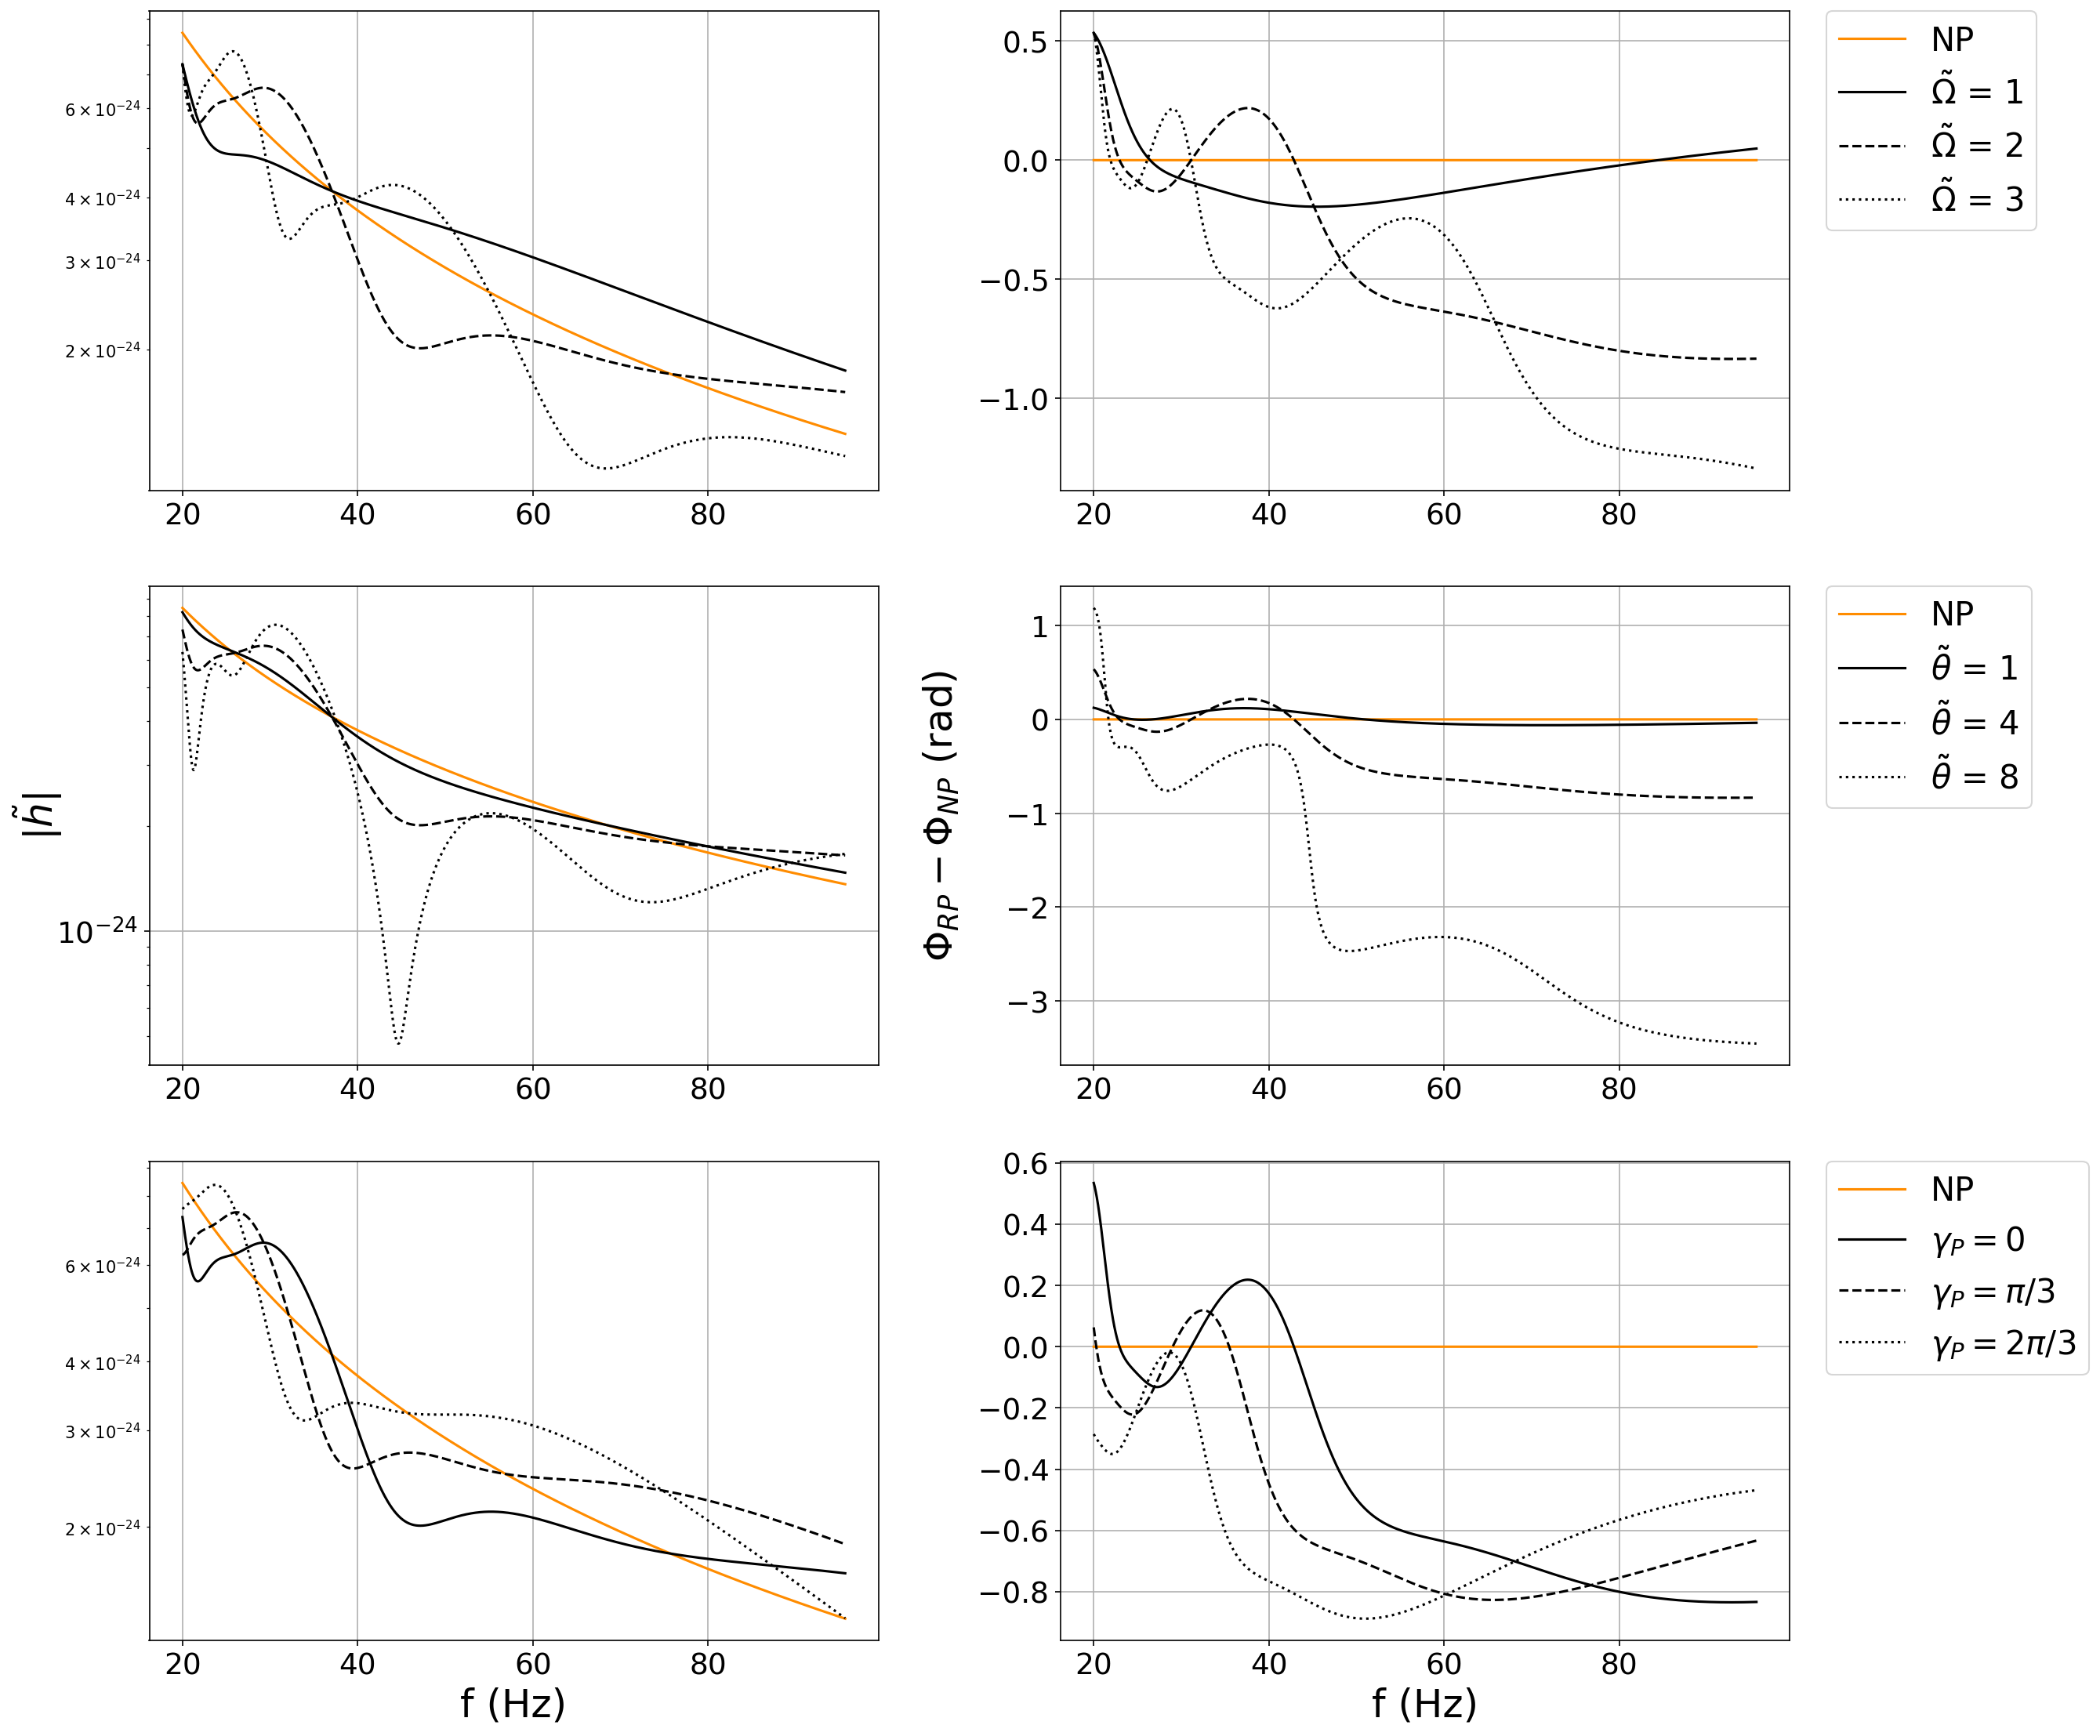

In [ ]:
# Precessing (random): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["random"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    delta_f=0.05,
    z=z,
)
print("system 3 in Taman's paper")

## edge-on

system 2 in Taman's paper


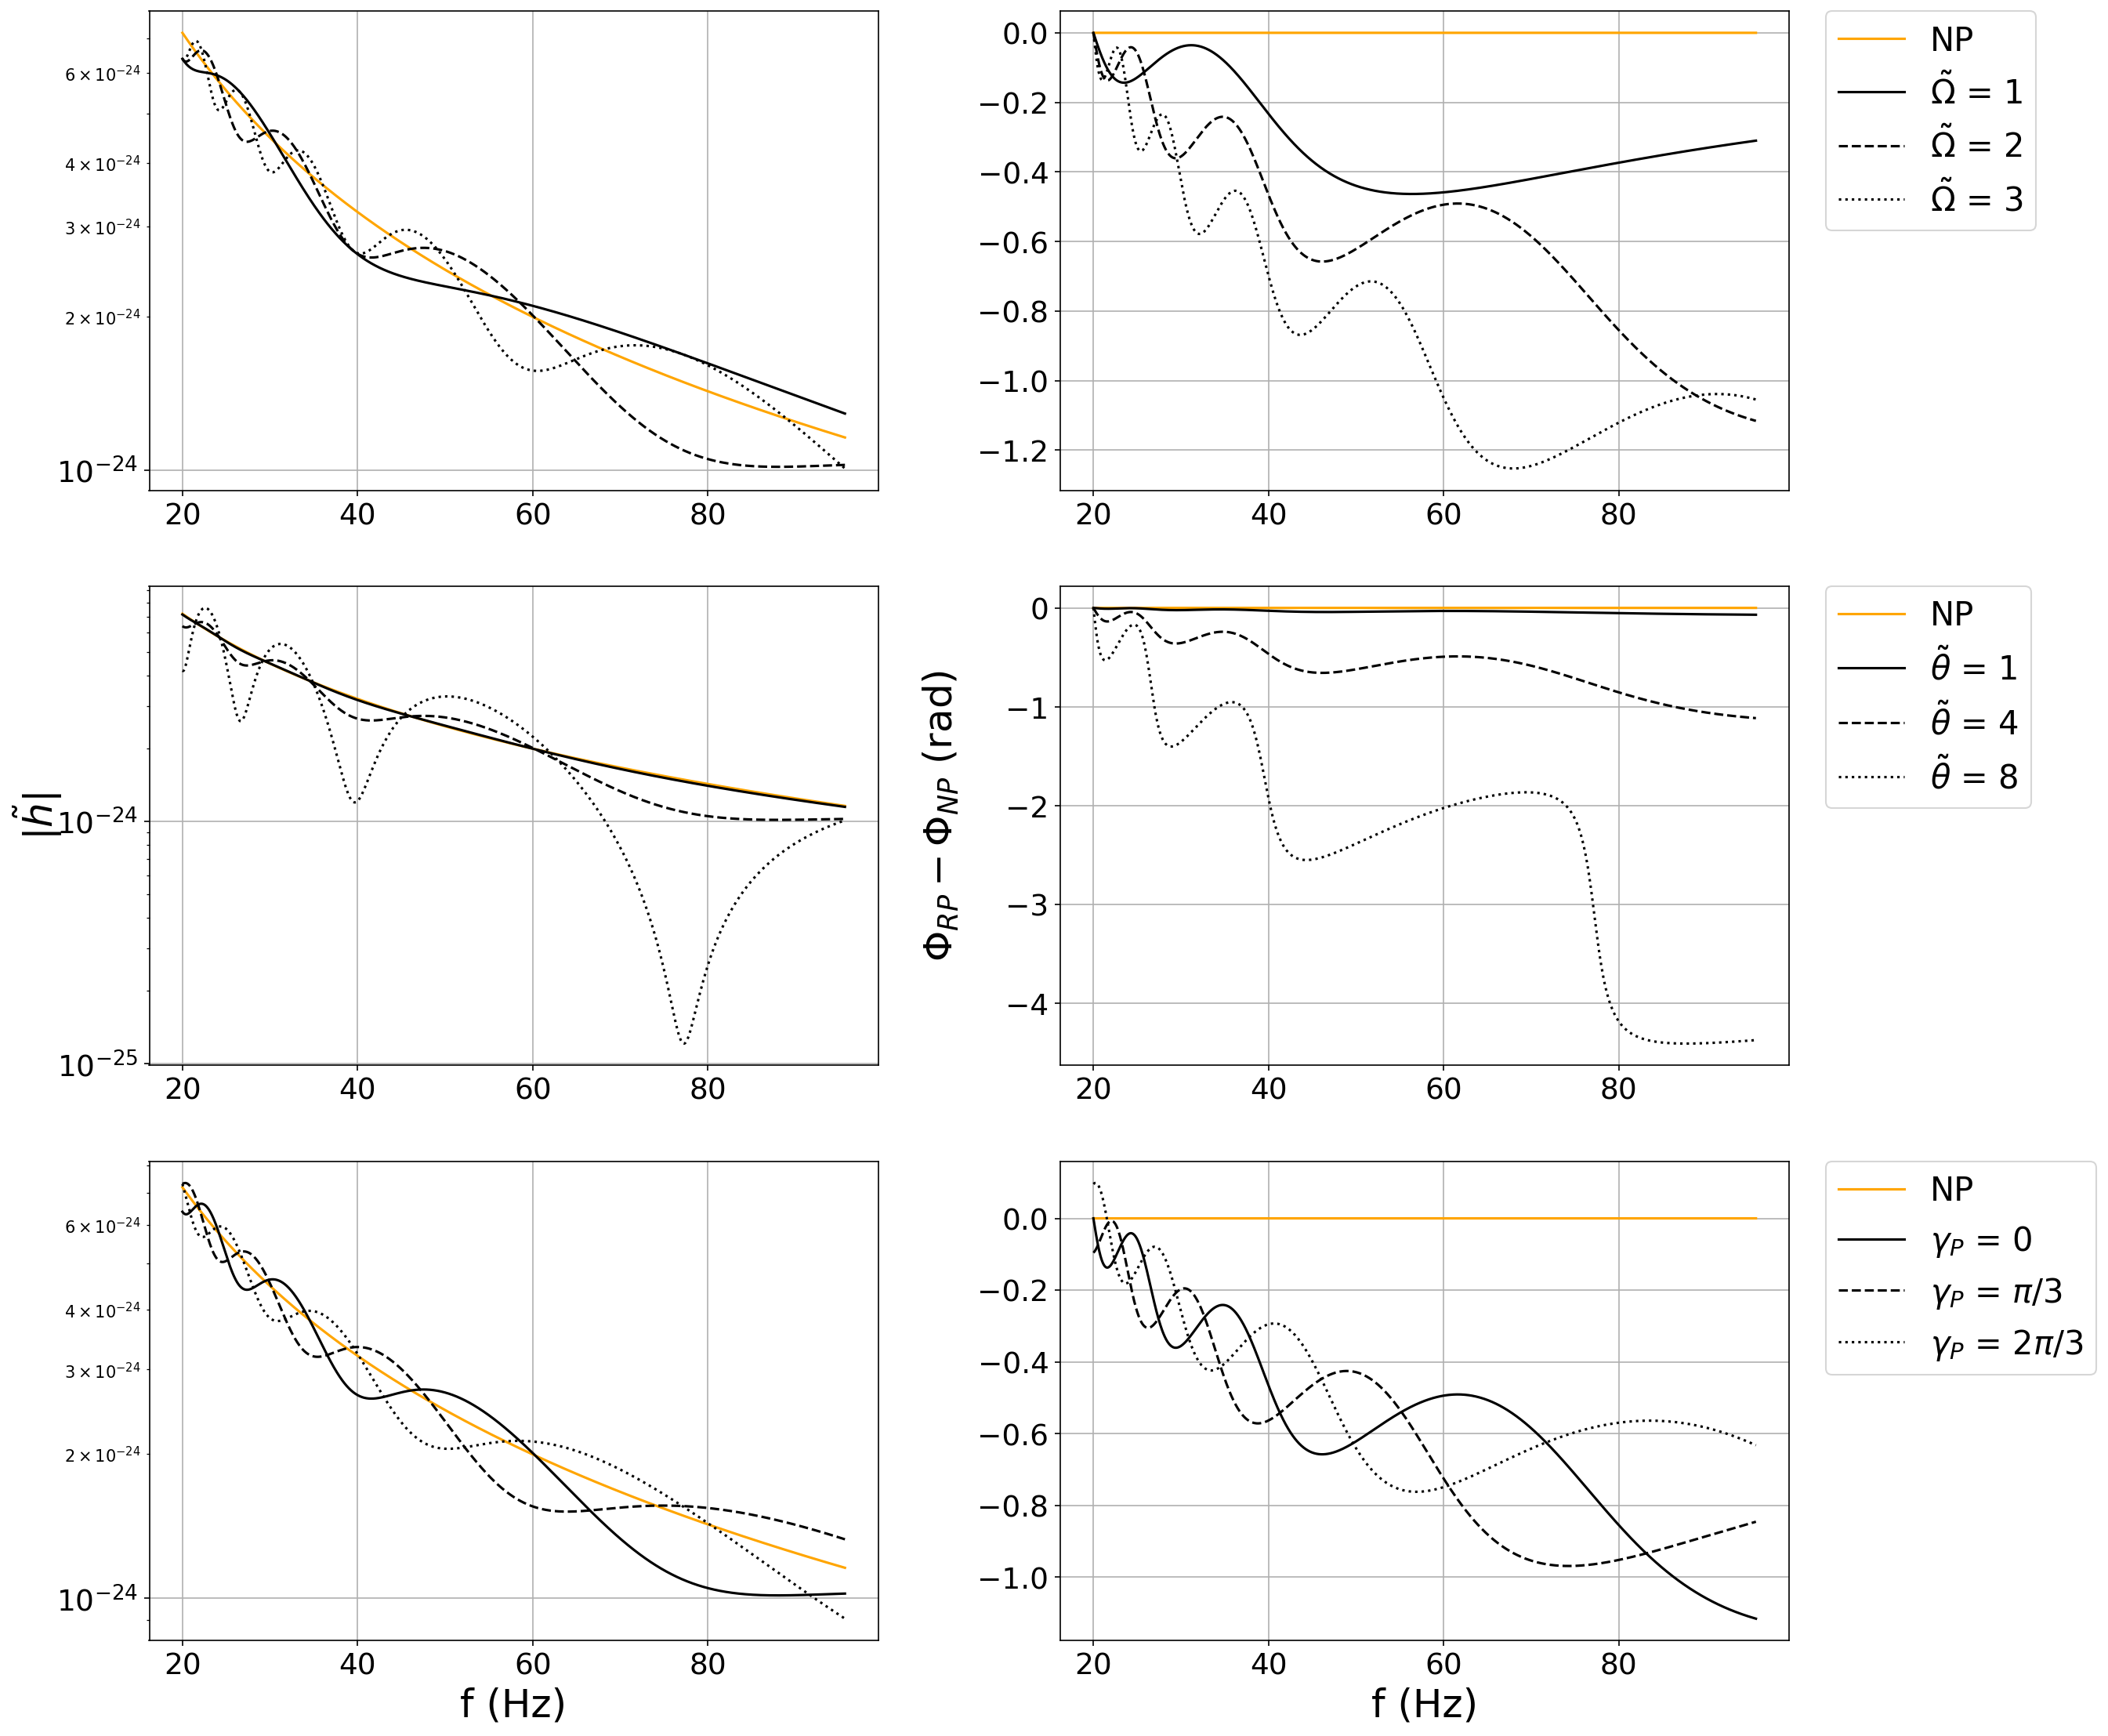

In [22]:
# Precessing (edge-on): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["edgeon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=z,
)
print("system 2 in Taman's paper")

system 2 in Taman's paper


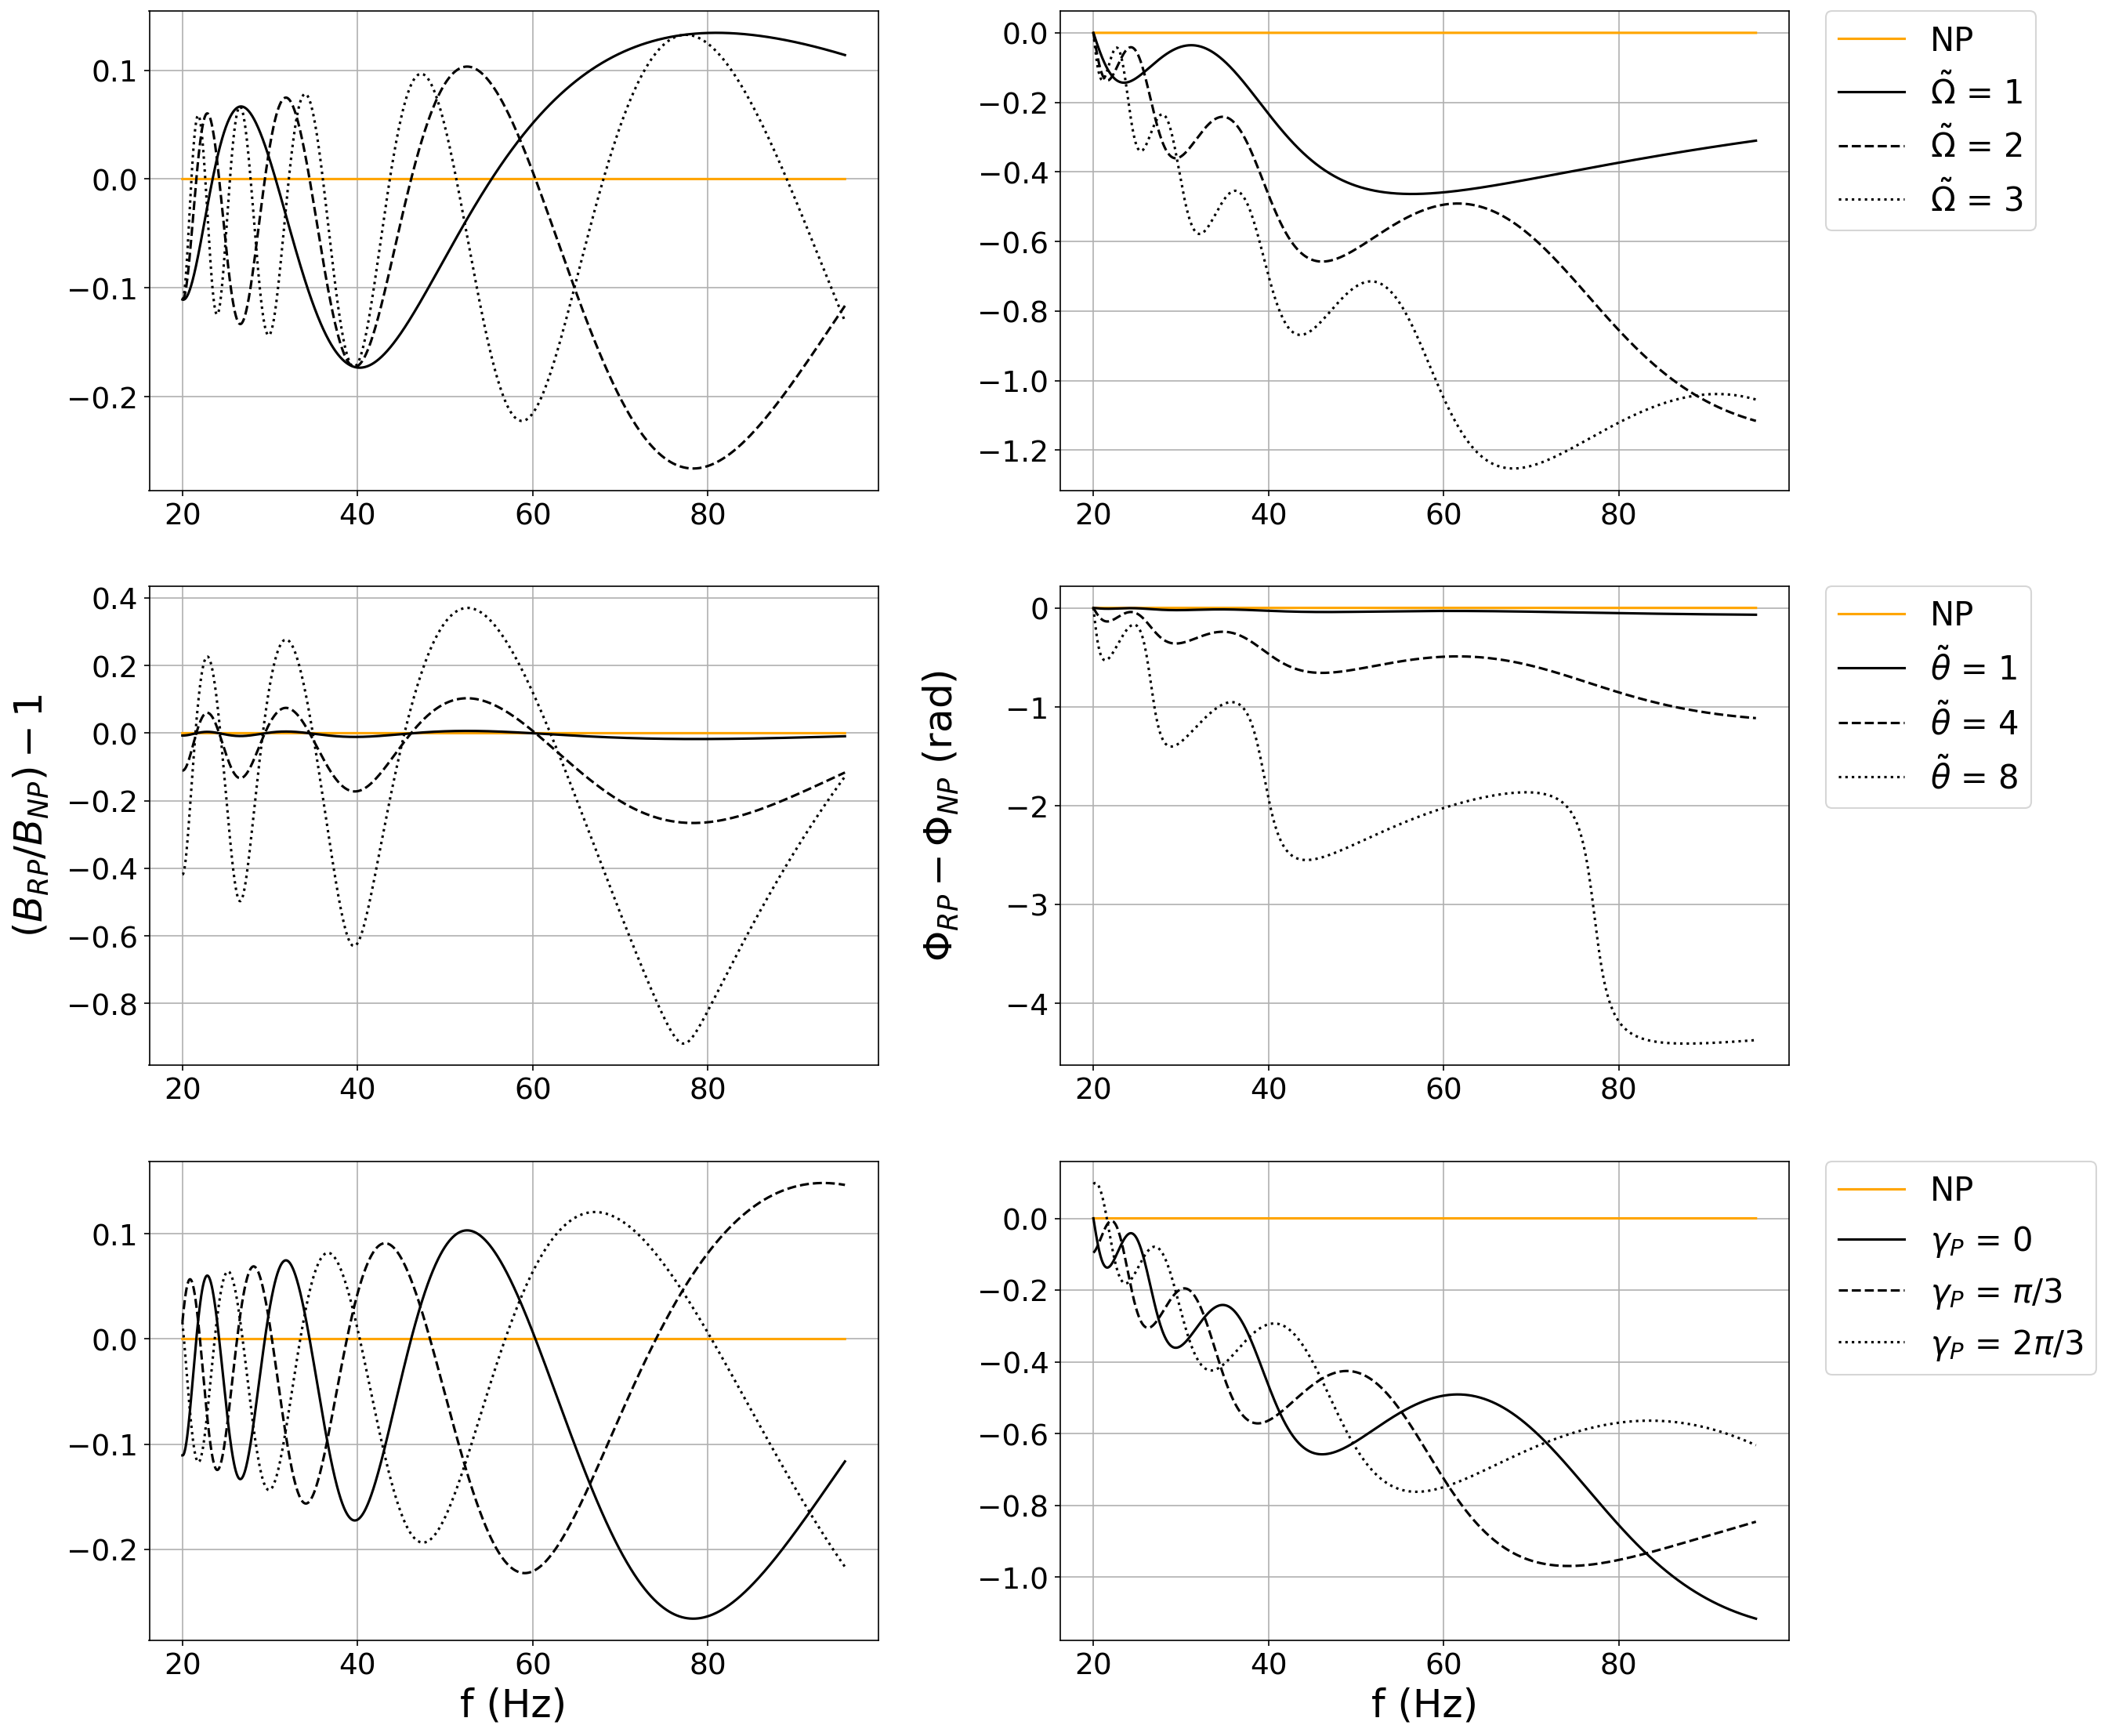

In [23]:
# Precessing (edge-on): amplitude ratio + phase via DRY helper
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=z,
    save_path="../figures/waveforms_RP_sys2.pdf",
)
print("system 2 in Taman's paper")

## face-on

system 1 in Taman's paper


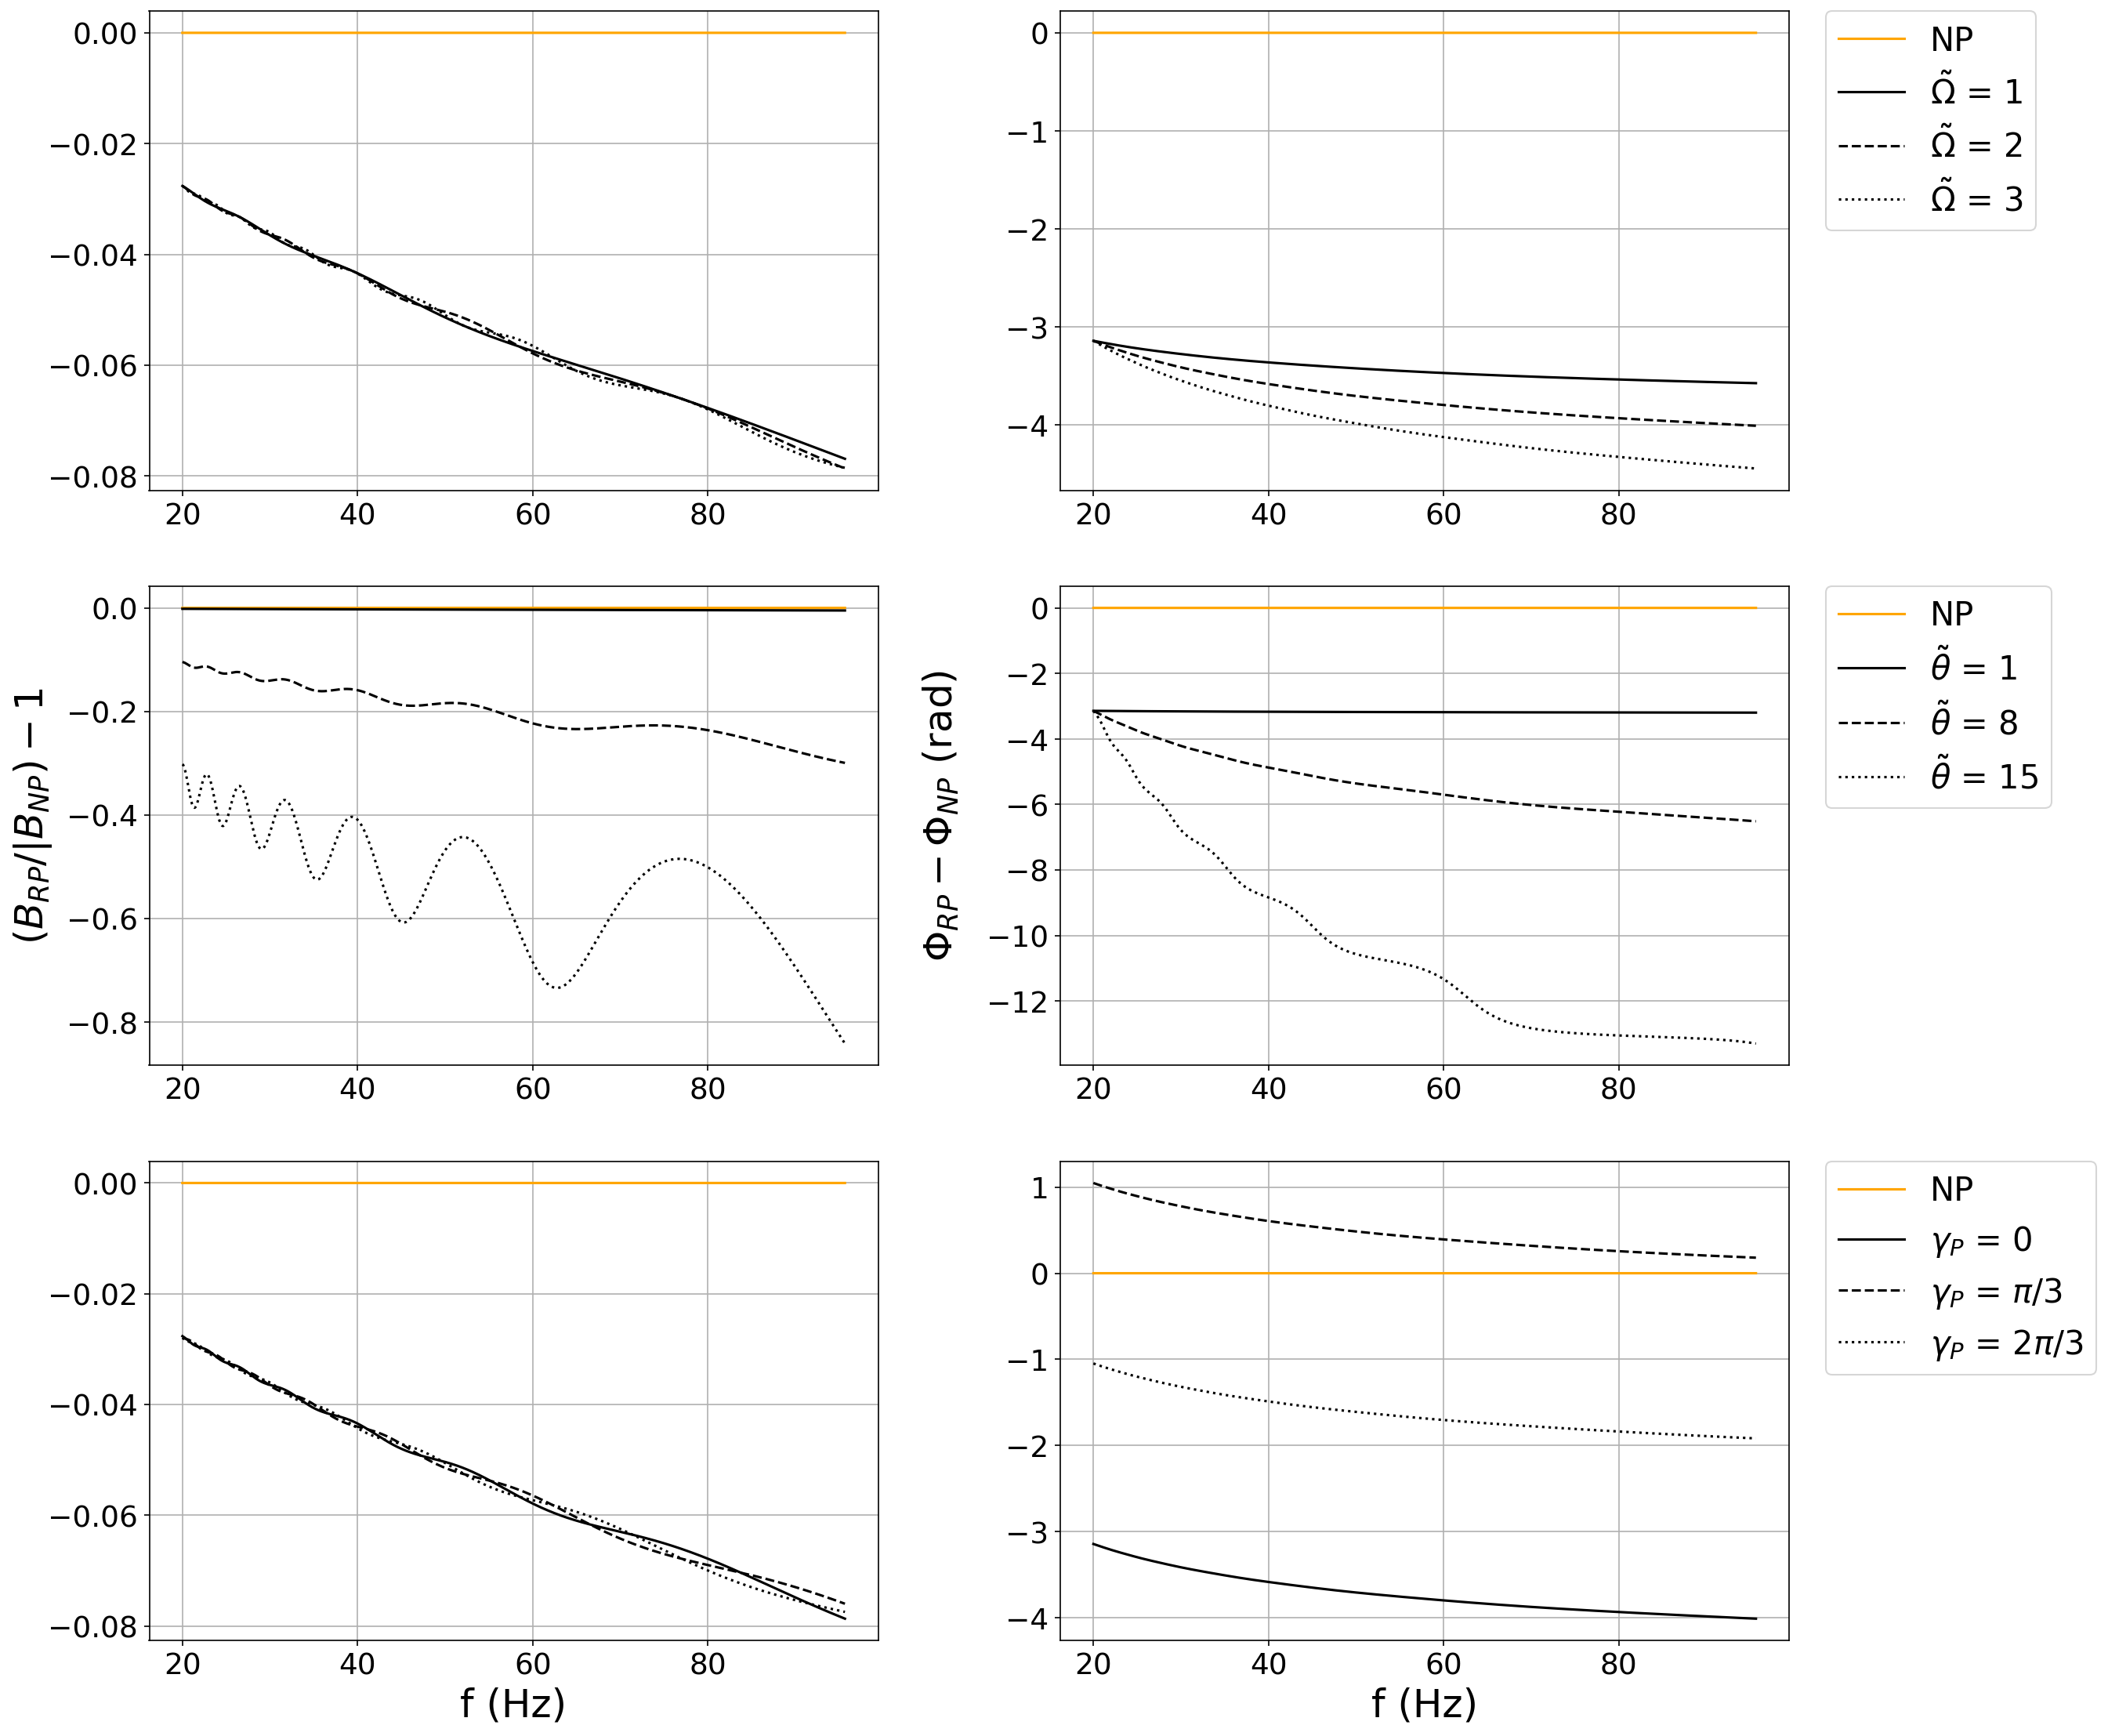

In [ ]:
# Precessing (face-on): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["faceon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 8, 15]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    z=z,
)
print("system 1 in Taman's paper")